In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

In [2]:
Scenario = 'Scenario_B'
ML_model = 'LightGBM_001'

## Model training

In [4]:
train_file_UiA = os.path.join(os.path.dirname(os.getcwd()),'6_Data_aggregation',
                             'US_UiA_Hourly_ECT_PSNDVI_ETa.csv')  # Change to your training file path

train_file_UiB = os.path.join(os.path.dirname(os.getcwd()),'6_Data_aggregation',
                             'US_UiB_Hourly_ECT_PSNDVI_ETa.csv')  # Change to your training file path

train_file_UiC = os.path.join(os.path.dirname(os.getcwd()),'6_Data_aggregation',
                             'US_UiC_Hourly_ECT_PSNDVI_ETa.csv')  # Change to your training file path

# Load the data; ensure that the timestamp column is parsed as dates.
UiA_train_df = pd.read_csv(train_file_UiA, index_col=0, parse_dates=[0])
UiB_train_df = pd.read_csv(train_file_UiB, index_col=0, parse_dates=[0])
UiC_train_df = pd.read_csv(train_file_UiC, index_col=0, parse_dates=[0])

train_df = pd.concat([UiA_train_df, UiB_train_df, UiC_train_df])

# Drop observations with nan NDVI values or ET_corr nan values
train_df_filtered = train_df[(train_df['NDVI']>0) & (train_df['ETa_corr']>0)]

train_df_filtered = train_df_filtered.rename(columns={'TA': 'Air Temperature', 'RH': 'relative_humidity',
                                                      'SW_IN':'Downward Short-Wave Radiation Flux',
                                                      'LW_IN':'Downward Long-Wave Radiation Flux',
                                                      'WS':'Wind Speed', 'PA':'Air Pressure',
                                                      'P_RAIN':'Total Precipitation'})

# Drop 'Downward Long-Wave Radiation Flux' and 'Total Precipitation' based on HXGB001 results
train_df_filtered = train_df_filtered.drop(columns=['Downward Long-Wave Radiation Flux', 'Total Precipitation', 'Wind Speed', 'Air Pressure'])

# train X and y
X_train_val = train_df_filtered.drop(columns=['ETa_corr', 'ETa_NaN_flag']).round(2)  # Training features
y_train_val = train_df_filtered['ETa_corr'].round(3) # Training target

In [5]:
X_train_val

,NDVI,Air Temperature,relative_humidity,Downward Short-Wave Radiation Flux
2019-05-25 06:00:00,0.49,23.14,76.72,239.95
2019-05-25 07:00:00,0.49,24.90,71.55,366.40
2019-05-25 08:00:00,0.50,25.66,69.38,490.80
2019-05-25 09:00:00,0.47,24.62,71.04,184.90
2019-05-25 10:00:00,0.45,25.14,70.04,445.40
...,...,...,...,...
2024-10-09 12:00:00,0.81,24.99,22.06,658.00
2024-10-09 13:00:00,0.81,25.76,21.00,579.80
2024-10-09 14:00:00,0.80,25.84,20.87,452.00
2024-10-09 15:00:00,0.80,25.62,20.81,288.45


In [6]:
def objective(trial):
    # Choose between two objectives: standard regression or huber loss for robustness.
    objective_choice = trial.suggest_categorical('objective', ['regression', 'huber'])
    
    param = {
        'objective': objective_choice,
        'metric': 'mae',
        'learning_rate': round(trial.suggest_float('learning_rate', 0.001, 0.1, log=True),3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 25),
        'min_data_in_leaf': 25,
        'feature_fraction': round(trial.suggest_float('feature_fraction', 0.1, 1.0),3),
        'bagging_fraction': round(trial.suggest_float('bagging_fraction', 0.1, 1.0),3),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1': round(trial.suggest_float('lambda_l1', 0.1, 10, log=True),3),
        'lambda_l2': round(trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),3),
        'feature_pre_filter': False,
        'verbose': -1,
    }

    # add constant params
    #param['feature_contri']= [1.0, 1.0, 1.0, 0.5],
    param['monotone_constraints']        = '1,0,0,0'
    param['monotone_constraints_method'] = 'intermediate'
    
    # Bin target into quantiles for stratification
    y_bins = pd.qcut(y_train_val, q=10, labels=False, duplicates='drop')

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    mae_scores = []
    
    for train_idx, valid_idx in skf.split(X_train_val, y_bins):
        X_train_fold, X_valid_fold = X_train_val.iloc[train_idx], X_train_val.iloc[valid_idx]
        y_train_fold, y_valid_fold = y_train_val.iloc[train_idx], y_train_val.iloc[valid_idx]

        lgb_train = lgb.Dataset(X_train_fold, y_train_fold)
        lgb_valid = lgb.Dataset(X_valid_fold, y_valid_fold, reference=lgb_train)

        gbm = lgb.train(
            param,
            lgb_train,
            num_boost_round=2500,
            valid_sets=[lgb_valid]
        )

        preds = gbm.predict(X_valid_fold, num_iteration=gbm.best_iteration)
        fold_mae = mean_absolute_error(y_valid_fold, preds)
        mae_scores.append(fold_mae)

    return np.mean(mae_scores)

# Create and run the study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=250)

# Display the best trial results
print("Best trial:")
print("  MAE: ", study.best_trial.value)
print("  Best hyperparameters: ", study.best_trial.params)

[I 2025-11-02 17:18:29,750] A new study created in memory with name: no-name-6bdfece5-dc13-4a58-9c6f-c0ffb3319f3f
[I 2025-11-02 17:18:41,073] Trial 0 finished with value: 0.08652996831357126 and parameters: {'objective': 'regression', 'learning_rate': 0.009380673003279728, 'num_leaves': 31, 'max_depth': 16, 'feature_fraction': 0.21605661880214166, 'bagging_fraction': 0.4239748136081444, 'bagging_freq': 1, 'lambda_l1': 0.24788084690588136, 'lambda_l2': 0.15492108321750617}. Best is trial 0 with value: 0.08652996831357126.
[I 2025-11-02 17:19:10,246] Trial 1 finished with value: 0.0877725736697704 and parameters: {'objective': 'huber', 'learning_rate': 0.017768818617463683, 'num_leaves': 81, 'max_depth': 21, 'feature_fraction': 0.27635052939450017, 'bagging_fraction': 0.884355991700843, 'bagging_freq': 2, 'lambda_l1': 0.2053340087608689, 'lambda_l2': 0.01871881613452373}. Best is trial 0 with value: 0.08652996831357126.
[I 2025-11-02 17:19:18,315] Trial 2 finished with value: 0.079677512

Best trial:
  MAE:  0.07643227615033524
  Best hyperparameters:  {'objective': 'regression', 'learning_rate': 0.003198848858920543, 'num_leaves': 33, 'max_depth': 9, 'feature_fraction': 0.9769491795777094, 'bagging_fraction': 0.9176762922010305, 'bagging_freq': 2, 'lambda_l1': 0.11448050781709063, 'lambda_l2': 2.5411005007771266}


In [7]:
# Retrieve the best hyperparameters from the study.
best_params = study.best_trial.params
best_params['feature_contri']= [2.0, 0.1, 0.1, 1.0]
best_params['monotone_constraints']= '1,0,0,0'
best_params['monotone_constraints_method']= 'intermediate'

lgb_train = lgb.Dataset(X_train_val, y_train_val)
lgb_val = lgb.Dataset(X_train_val, y_train_val, reference=lgb_train)

# Train the final model.
final_model = lgb.train(
    best_params,
    lgb_train,
    num_boost_round=5000,             
    valid_sets=[lgb_val]
)

clear_output(wait=False)

In [8]:
final_model.save_model('ScenarioB_lgbm_final_model_001_IL.txt')

In [9]:
print("Features in order:", final_model.feature_name())
print("Monotone constraints:", final_model.params.get('monotone_constraints'))

Features in order: ['NDVI', 'Air_Temperature', 'relative_humidity', 'Downward_Short-Wave_Radiation_Flux']
Monotone constraints: 1,0,0,0


In [10]:
final_model.params

{'objective': 'regression',
 'learning_rate': 0.003198848858920543,
 'num_leaves': 33,
 'max_depth': 9,
 'feature_fraction': 0.9769491795777094,
 'bagging_fraction': 0.9176762922010305,
 'bagging_freq': 2,
 'lambda_l1': 0.11448050781709063,
 'lambda_l2': 2.5411005007771266,
 'feature_contri': [2.0, 0.1, 0.1, 1.0],
 'monotone_constraints': '1,0,0,0',
 'monotone_constraints_method': 'intermediate',
 'num_iterations': 5000}

In [11]:
final_model.feature_name()

['NDVI',
 'Air_Temperature',
 'relative_humidity',
 'Downward_Short-Wave_Radiation_Flux']

## Model traning evaluation

In [1]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.io import output_notebook
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import lightgbm as lgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [2]:
def predict_LGBM(model, X_df, y_df, prediction_col='ETa_predicted'):

    
    preds = model.predict(X_df)
    
    # Create a copy of the DataFrame and add the predictions column.
    df_with_preds = pd.concat([X_df, y_df], axis=1).copy()
    df_with_preds[prediction_col] = preds
    
    return df_with_preds

In [3]:
def plot_interactive_scatter_by_year(df, col1, col2):
    """
    Creates an interactive scatter plot using Bokeh.
    - X-axis represents col1.
    - Y-axis represents col2.
    - Dots are color-coded by year.
    - R² values for each year are displayed in the legend.
    - A 45-degree reference line is added.

    Parameters:
    df (pd.DataFrame): DataFrame with a datetime index.
    col1 (str): Column name for x-axis.
    col2 (str): Column name for y-axis.
    """

    # Ensure the index is in datetime format
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Extract year from index
    df['Year'] = df.index.year

    # Drop NaN values to avoid errors
    df = df.dropna(subset=[col1, col2])

    # Define colors for each year using a colormap
    unique_years = df['Year'].unique()
    colors = plt.cm.get_cmap('tab10', len(unique_years))  # Generate distinct colors

    # Initialize Bokeh figure
    p = figure(title=f"Interactive Scatter Plot: {col1} vs {col2}",
               x_axis_label=col1, y_axis_label=col2,
               width=500, height=500,
               tools="pan,box_zoom,wheel_zoom,reset,save",
               toolbar_location="above")

    # Determine the min and max values for equal scaling
    min_val = min(df[col1].min(), df[col2].min())
    max_val = max(df[col1].max(), df[col2].max())
    one_to_one_x = np.array([min_val, max_val])
    one_to_one_y = np.array([min_val, max_val])

    # Plot 45-degree reference line
    p.line(one_to_one_x, one_to_one_y, line_width=2, color="red", line_dash="dashed", legend_label="1:1 Line")

    # Store R² values for legend
    r2_legend_labels = []

    # Plot each year separately
    for i, year in enumerate(unique_years):
        df_year = df[df['Year'] == year]

        # Fit linear regression model and compute R²
        model = LinearRegression()
        x_values = df_year[col1].values.reshape(-1, 1)
        y_values = df_year[col2].values.reshape(-1, 1)
        model.fit(x_values, y_values)
        r2 = model.score(x_values, y_values)

        # Store R² value for legend
        r2_legend_labels.append(f"{year} (R² = {r2:.2f})")

        # Create data source for Bokeh
        source = ColumnDataSource(data={
            "x": df_year[col1],
            "y": df_year[col2],
            "time": df_year.index.strftime("%Y-%m-%d %H:%M"),  # Format datetime for tooltips
        })

        # Plot scatter points for each year
        p.scatter("x", "y", source=source, size=8, color='blue', alpha=0.6, legend_label=r2_legend_labels[-1])

    # Add hover tool
    hover = HoverTool(
        tooltips=[(col1, "@x"), (col2, "@y"), ("Time", "@time")],
        mode="mouse"
    )
    p.add_tools(hover)

    # Enable toggling elements by clicking the legend
    p.legend.click_policy = "hide"
    p.legend.background_fill_alpha = 0.5

    # Show the plot
    show(p)

In [4]:
final_model = lgb.Booster(model_file='ScenarioB_lgbm_final_model_001_IL.txt')

In [5]:
UiA_AORC_train_file = os.path.join(os.path.dirname(os.getcwd()), '8_Data_prepration_prediction_phase',
                             'US_UiA_Hourly_AORC_PSNDVI_ETa.csv')
UiB_AORC_train_file = os.path.join(os.path.dirname(os.getcwd()), '8_Data_prepration_prediction_phase',
                             'US_UiB_Hourly_AORC_PSNDVI_ETa.csv')
UiC_AORC_train_file = os.path.join(os.path.dirname(os.getcwd()), '8_Data_prepration_prediction_phase',
                             'US_UiC_Hourly_AORC_PSNDVI_ETa.csv')

VT1_AORC_train_file = os.path.join(os.path.dirname(os.getcwd()), '8_Data_prepration_prediction_phase',
                             'US_VT1_Hourly_AORC_PSNDVI_ETa.csv')
VT2_AORC_train_file = os.path.join(os.path.dirname(os.getcwd()), '8_Data_prepration_prediction_phase',
                             'US_VT2_Hourly_AORC_PSNDVI_ETa.csv')

# Load the data; ensure that the timestamp column is parsed as dates.
UiA_AORC_train_df = pd.read_csv(UiA_AORC_train_file, index_col=0, parse_dates=[0])
UiB_AORC_train_df = pd.read_csv(UiB_AORC_train_file, index_col=0, parse_dates=[0])
UiC_AORC_train_df = pd.read_csv(UiC_AORC_train_file, index_col=0, parse_dates=[0])

VT1_AORC_train_df = pd.read_csv(VT1_AORC_train_file, index_col=0, parse_dates=[0])
VT2_AORC_train_df = pd.read_csv(VT2_AORC_train_file, index_col=0, parse_dates=[0])


# Drop observations with nan NDVI values or ET_corr nan values
UiA_AORC_train_df_filtered = UiA_AORC_train_df[(UiA_AORC_train_df['NDVI']>0) & (UiA_AORC_train_df['ETa_corr']>0)]
UiB_AORC_train_df_filtered = UiB_AORC_train_df[(UiB_AORC_train_df['NDVI']>0) & (UiB_AORC_train_df['ETa_corr']>0)]
UiC_AORC_train_df_filtered = UiC_AORC_train_df[(UiC_AORC_train_df['NDVI']>0) & (UiC_AORC_train_df['ETa_corr']>0)]

VT1_AORC_train_df_filtered = VT1_AORC_train_df[(VT1_AORC_train_df['NDVI']>0) & (VT1_AORC_train_df['ETa_corr']>0)]
VT2_AORC_train_df_filtered = VT2_AORC_train_df[(VT2_AORC_train_df['NDVI']>0) & (VT2_AORC_train_df['ETa_corr']>0)]

# List of input feature columns
input_features_list = ['NDVI',
 'Air Temperature',
 'relative_humidity',
 'Downward Short-Wave Radiation Flux']

UiA_X_test_train = UiA_AORC_train_df_filtered[input_features_list]
UiA_y_test_train = UiA_AORC_train_df_filtered['ETa_corr']

UiB_X_test_train = UiB_AORC_train_df_filtered[input_features_list]
UiB_y_test_train = UiB_AORC_train_df_filtered['ETa_corr']

UiC_X_test_train = UiC_AORC_train_df_filtered[input_features_list]
UiC_y_test_train = UiC_AORC_train_df_filtered['ETa_corr']

VT1_X_test_train = VT1_AORC_train_df_filtered[input_features_list]
VT1_y_test_train = VT1_AORC_train_df_filtered['ETa_corr']

VT2_X_test_train = VT2_AORC_train_df_filtered[input_features_list]
VT2_y_test_train = VT2_AORC_train_df_filtered['ETa_corr']

In [6]:
UiA_df_test_w_preds = predict_LGBM(final_model, UiA_X_test_train, UiA_y_test_train, prediction_col='ETa_predicted')
plot_interactive_scatter_by_year(UiA_df_test_w_preds, 'ETa_corr', 'ETa_predicted')

ValueError: Input data must be 2 dimensional and non empty.

In [7]:
UiB_df_test_w_preds = predict_LGBM(final_model, UiB_X_test_train, UiB_y_test_train, prediction_col='ETa_predicted')
plot_interactive_scatter_by_year(UiB_df_test_w_preds, 'ETa_corr', 'ETa_predicted')

C:\Users\adadkhah\AppData\Local\Temp\ipykernel_14816\950240399.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_years))  # Generate distinct colors


In [8]:
UiC_df_test_w_preds = predict_LGBM(final_model, UiC_X_test_train, UiC_y_test_train, prediction_col='ETa_predicted')
plot_interactive_scatter_by_year(UiC_df_test_w_preds, 'ETa_corr', 'ETa_predicted')

C:\Users\adadkhah\AppData\Local\Temp\ipykernel_14816\950240399.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_years))  # Generate distinct colors


In [9]:
VT1_df_test_w_preds = predict_LGBM(final_model, VT1_X_test_train, VT1_y_test_train, prediction_col='ETa_predicted')
plot_interactive_scatter_by_year(VT1_df_test_w_preds, 'ETa_corr', 'ETa_predicted')

C:\Users\adadkhah\AppData\Local\Temp\ipykernel_14816\950240399.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_years))  # Generate distinct colors


In [10]:
VT2_df_test_w_preds = predict_LGBM(final_model, VT2_X_test_train, VT2_y_test_train, prediction_col='ETa_predicted')
plot_interactive_scatter_by_year(VT2_df_test_w_preds, 'ETa_corr', 'ETa_predicted')

C:\Users\adadkhah\AppData\Local\Temp\ipykernel_14816\950240399.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_years))  # Generate distinct colors


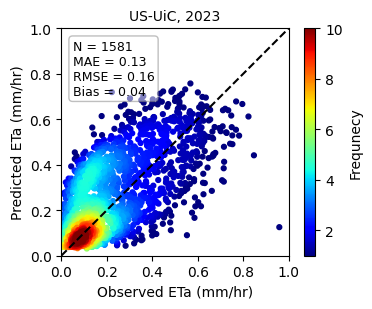

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from matplotlib.ticker import FormatStrFormatter

# Assuming df['actual'] and df['predicted'] exist
x = UiC_df_test_w_preds.loc['2023']['ETa_corr'].values
y = UiC_df_test_w_preds.loc['2023']['ETa_predicted'].values


# Stack them and calculate the point density
xy = np.vstack([x, y])
kde = gaussian_kde(xy)
kde.set_bandwidth(bw_method=0.3)
z = kde(xy)  # z is the density estimate
# Optional: sort so densest points are plotted last (on top)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

# Error metrics
n = len(x)
r2 = r2_score(x, y)
mae = mean_absolute_error(x, y)
rmse = np.sqrt(mean_squared_error(x, y))
bias = np.mean(y - x)

# Plot
plt.figure(figsize=(4,3.2))
sc = plt.scatter(x, y, c=z, cmap='jet', s=12, vmin=1, vmax=10)
plt.colorbar(sc, label='Frequnecy')
plt.plot([0, 1], [0, 1], linestyle='--', color='black')

textstr = f'N = {n}\nMAE = {mae:.2f}\nRMSE = {rmse:.2f}\nBias = {bias:0.2f}'
plt.text(
    0.05, 0.95, textstr,
    transform=plt.gca().transAxes,  # Use axes coords (0–1)
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray',alpha=0.5)
)

# Set square plot area
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plt.xlabel('Observed ETa (mm/hr)')
plt.ylabel('Predicted ETa (mm/hr)')
plt.xlim(0,1)
plt.ylim(0,1)
plt.title('US-UiC, 2023', fontsize=10)
xmin, xmax = plt.gca().get_xlim()
ymin, ymax = plt.gca().get_ylim()

N = 6   # number of ticks

plt.xticks(np.linspace(xmin, xmax, N))
plt.yticks(np.linspace(ymin, ymax, N))
#plt.legend()
plt.tight_layout()
plt.savefig('US_UiC_2023_Actual_vs_Predcited_ETa_plot_with_colorbar.png', dpi=300, transparent=True)
plt.show()